In [1]:
# make sure to choose the python_course environment+activate conda

# import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\stuco\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# filter for US Data Analyst jobs
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

#remove NaN values so plotting is accurate
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US['salary_year_avg'].sample(10)

489708     80500.0
313686     99150.0
671348    105000.0
485678     96500.0
196642    140875.0
740619     82500.0
242081    115000.0
738132     54233.0
513268     66455.5
292166     77500.0
Name: salary_year_avg, dtype: float64

C:\Users\stuco\AppData\Local\Temp\ipykernel_7496\2740423560.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels=job_titles, vert=False) # newest boxplot function uses tick_labels'


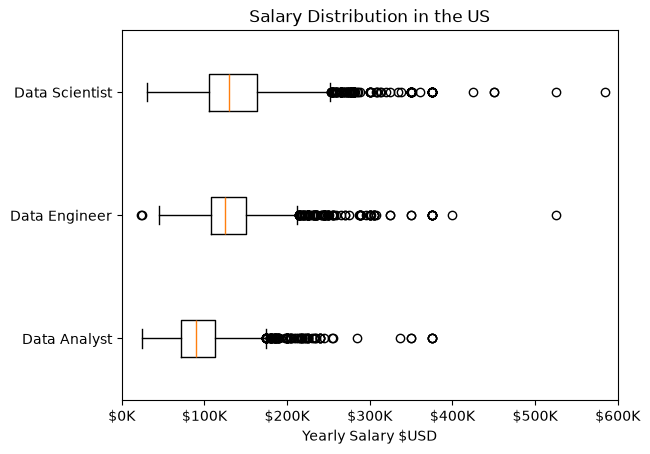

In [32]:
job_titles = ['Data Analyst', 'Data Engineer', "Data Scientist"]

# filter the data to appropriate job titles
# we only want data analyst jobs, use this filter from earlier
# we can use .isin() to direct this line of code to see if job_titles is in job_title_short
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])
# list comprehension
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels=job_titles, vert=False) # newest boxplot function uses tick_labels'
plt.title("Salary Distribution in the US")
plt.xlabel('Yearly Salary $USD')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

# we have one outlier way out at 1000K, we'll filter it out but keep it noted, we'll focus on up to 600K, use xlim



In [1]:
import seaborn as sns

sns.boxplot(data=df_US, x="salary_year_avg", y="job_title_short")
sns.set_theme(style="ticks")

plt.title("Salary Distribution in the US")
plt.ylabel('')
plt.xlabel('Yearly Salary $USD')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

NameError: name 'df_US' is not defined